<a href="https://colab.research.google.com/github/Anisha2810/Neural-networks-and-deep-learning/blob/main/time_series_forecasting_using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 50/200, Loss: 0.0026
Epoch 100/200, Loss: 0.0021
Epoch 150/200, Loss: 0.0020
Epoch 200/200, Loss: 0.0019


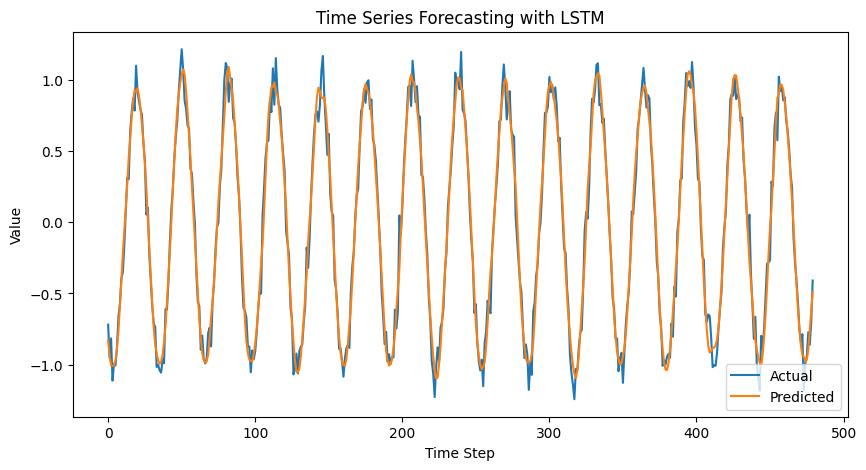

In [1]:
# Install required packages
!pip -q install torch matplotlib numpy pandas scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# 1. Create synthetic time series
# -----------------------------
time_steps = np.linspace(0, 100, 500)
data = np.sin(time_steps) + 0.1 * np.random.randn(len(time_steps))  # sine wave with noise
data = data.reshape(-1, 1)

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Prepare sequences
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 20
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# Convert to PyTorch tensors
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

# -----------------------------
# 2. Define LSTM model
# -----------------------------
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# -----------------------------
# 3. Train the model
# -----------------------------
EPOCHS = 200
for epoch in range(EPOCHS):
    output = model(X)
    loss = criterion(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.4f}')

# -----------------------------
# 4. Make predictions
# -----------------------------
predicted = model(X).detach().numpy()
predicted = scaler.inverse_transform(predicted)
actual = scaler.inverse_transform(y.numpy())

# -----------------------------
# 5. Plot results
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(actual, label='Actual')
plt.plot(predicted, label='Predicted')
plt.title("Time Series Forecasting with LSTM")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()